# LangChain + LangGraph Agent Patterns Guide
## RAG | Reflection | Tool Use | ReAct | Planning | Multi-Agent

This notebook covers:
1. RAG Without LangChain (manual implementation)
2. RAG With LangChain (LCEL pipeline)
3. LangGraph ReAct Agent with Tools and Guardrails
4. Five Agent Design Patterns:
   - 4-A: Reflection Pattern — Blog headline writer
   - 4-B: Tool Use Pattern  — Travel research assistant
   - 4-C: ReAct Pattern     — Software bug triage
   - 4-D: Planning Pattern  — Marketing campaign planner
   - 4-E: Multi-Agent Pattern — News article pipeline
5. LangSmith Tracing

Model used throughout: `gpt-4o-mini`


---
## SECTION 0 - Installation and Setup

In [1]:
import subprocess, sys

packages = [
    "openai", "langchain", "langchain-openai", "langchain-community",
    "langchain-core", "langgraph", "langsmith",
    "faiss-cpu", "tiktoken", "numpy", "requests", "python-dotenv", "chromadb"
]

print("📦 Installing dependencies...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + packages, check=True)
print("✅ All dependencies installed successfully")

📦 Installing dependencies...
✅ All dependencies installed successfully


In [2]:
# ── API Keys (Colab-friendly) ─────────────────────────────────────────────────
import os

# Option A: Colab Secrets (recommended) — set OPENAI_API_KEY in the key icon
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("[SETUP] Loaded key from Colab Secrets")
except Exception:
    pass  # not in Colab — set key below

# Option B: paste key directly (remove before sharing!)
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = ""   # <-- paste here

# LangSmith (optional)
os.environ.setdefault("LANGCHAIN_TRACING_V2", "false")
os.environ.setdefault("LANGCHAIN_PROJECT", "agent-patterns")

key = os.environ.get("OPENAI_API_KEY", "")
print(f"[SETUP] OpenAI key: {'set' if key.startswith('sk-') else 'MISSING — fill in above'}")


[SETUP] Loaded key from Colab Secrets
[SETUP] OpenAI key: set


In [3]:
from openai import OpenAI

client = OpenAI()   # reads OPENAI_API_KEY from env
print("✅ OpenAI client initialized")

✅ OpenAI client initialized


---
## SECTION 1 - RAG Without LangChain

Every component is built manually:
- **Chunking** – character-level sliding window
- **Embeddings** – direct OpenAI API call
- **Vector store** – in-memory cosine similarity
- **Retrieval + Generation** – full RAG pipeline

In [4]:
# ── Document ──────────────────────────────────────────────────────────────────
RAW_DOCUMENT = """
LangChain is a framework designed to simplify the creation of applications using large language models (LLMs).
It provides tools for chaining prompts, managing memory, integrating with external data sources, and building agents.

LangGraph is a library built on top of LangChain that enables building stateful, multi-actor applications with LLMs.
It uses a graph-based architecture where nodes represent computation steps and edges represent transitions.
LangGraph is particularly useful for building complex agent workflows that require cycles and branching logic.

LangSmith is a developer platform for debugging, testing, evaluating, and monitoring LLM applications.
It provides tracing capabilities that allow developers to see every step of an LLM chain or agent run.
LangSmith integrates seamlessly with LangChain and LangGraph.

RAG stands for Retrieval-Augmented Generation. It is a technique where relevant documents are retrieved
from a knowledge base and provided to the LLM as context before generating a response.
RAG helps reduce hallucinations and allows the model to answer questions about private or recent data.

Embeddings are numerical vector representations of text. Similar texts produce similar embedding vectors.
This property allows us to find semantically similar documents using distance metrics like cosine similarity.
OpenAI's text-embedding-ada-002 and text-embedding-3-small are commonly used embedding models.

Vector stores are databases optimized for storing and searching embedding vectors.
FAISS (Facebook AI Similarity Search) is a popular open-source vector store for fast nearest-neighbor search.
Other vector stores include Chroma, Pinecone, Weaviate, and Qdrant.

Agents are LLM-powered systems that can use tools to accomplish tasks.
A tool is a function that the agent can call, such as a web search, calculator, or API call.
Agents decide which tools to use and in what order based on the user's query.
"""

print(f"[DOCUMENT] {len(RAW_DOCUMENT)} chars | {len(RAW_DOCUMENT.split())} words")

[DOCUMENT] 1948 chars | 278 words


In [5]:
# ── Optional: load from PDF instead ──────────────────────────────────────────
# from langchain_community.document_loaders import PyPDFLoader
#
# loader = PyPDFLoader("your_file.pdf")
# pdf_docs = loader.load()
# RAW_DOCUMENT = "\n\n".join(doc.page_content.strip() for doc in pdf_docs if doc.page_content.strip())
# print(f"[PDF] {len(pdf_docs)} pages | {len(RAW_DOCUMENT)} chars")

In [6]:
# ── Chunking ──────────────────────────────────────────────────────────────────
def chunk_text(text: str, chunk_size: int = 200, overlap: int = 40) -> list[str]:
    """Split text into overlapping character-level chunks by paragraph."""
    paragraphs = [p.strip() for p in text.strip().split("\n\n") if p.strip()]
    chunks = []
    for para in paragraphs:
        start = 0
        while start < len(para):
            chunk = para[start : start + chunk_size].strip()
            if chunk:
                chunks.append(chunk)
            start += chunk_size - overlap
    return chunks


chunks = chunk_text(RAW_DOCUMENT, chunk_size=250, overlap=50)
print(f"[CHUNKING] {len(chunks)} chunks produced")
for i, chunk in enumerate(chunks, 1):
    print(f"  Chunk {i:02d} ({len(chunk)} chars): {chunk[:80]}...")

[CHUNKING] 14 chunks produced
  Chunk 01 (228 chars): LangChain is a framework designed to simplify the creation of applications using...
  Chunk 02 (28 chars): ources, and building agents....
  Chunk 03 (250 chars): LangGraph is a library built on top of LangChain that enables building stateful,...
  Chunk 04 (135 chars): s represent transitions.
LangGraph is particularly useful for building complex a...
  Chunk 05 (250 chars): LangSmith is a developer platform for debugging, testing, evaluating, and monito...
  Chunk 06 (66 chars): run.
LangSmith integrates seamlessly with LangChain and LangGraph....
  Chunk 07 (250 chars): RAG stands for Retrieval-Augmented Generation. It is a technique where relevant ...
  Chunk 08 (92 chars): reduce hallucinations and allows the model to answer questions about private or ...
  Chunk 09 (250 chars): Embeddings are numerical vector representations of text. Similar texts produce s...
  Chunk 10 (110 chars): ine similarity.
OpenAI's text-embedding-ada

In [7]:
# ── Embeddings ────────────────────────────────────────────────────────────────
import numpy as np

def get_embeddings(texts: list[str], model: str = "text-embedding-3-small") -> list:
    """Embed texts in batches of 2000 to stay within API limits."""
    all_vectors = []
    for i in range(0, len(texts), 2000):
        batch = texts[i : i + 2000]
        response = client.embeddings.create(input=batch, model=model)
        all_vectors.extend(item.embedding for item in response.data)
    print(f"[EMBEDDINGS] {len(all_vectors)} vectors | dim={len(all_vectors[0])}")
    return all_vectors


chunk_embeddings = get_embeddings(chunks)

[EMBEDDINGS] 14 vectors | dim=1536


In [8]:
# ── In-Memory Vector Store ────────────────────────────────────────────────────
class SimpleVectorStore:
    """Minimal in-memory vector store using cosine similarity."""

    def __init__(self):
        self.texts: list[str] = []
        self.embeddings: list[np.ndarray] = []

    def add(self, texts: list[str], embeddings: list) -> None:
        self.texts.extend(texts)
        self.embeddings.extend(np.array(e) for e in embeddings)
        print(f"[VECTOR STORE] {len(self.texts)} documents indexed")

    @staticmethod
    def _cosine(a: np.ndarray, b: np.ndarray) -> float:
        return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))

    def search(self, query_embedding: list, top_k: int = 3) -> list[tuple[float, str]]:
        q = np.array(query_embedding)
        scored = sorted(
            ((self._cosine(q, e), t) for e, t in zip(self.embeddings, self.texts)),
            reverse=True
        )
        return scored[:top_k]


vector_store = SimpleVectorStore()
vector_store.add(chunks, chunk_embeddings)

[VECTOR STORE] 14 documents indexed


In [9]:
# ── RAG Pipeline ─────────────────────────────────────────────────────────────
def rag_query_no_langchain(question: str, top_k: int = 3) -> str:
    """End-to-end RAG: embed → retrieve → generate."""
    print(f"\n{'='*60}\n[RAG] {question}\n{'='*60}")

    query_vec = get_embeddings([question])[0]
    results   = vector_store.search(query_vec, top_k=top_k)

    print(f"[RETRIEVE] Top {top_k} chunks:")
    for rank, (score, text) in enumerate(results, 1):
        print(f"  {rank}. score={score:.4f} | {text[:100]}...")

    context = "\n\n".join(text for _, text in results)
    prompt = (
        "You are a helpful assistant. Use ONLY the context below to answer.\n"
        "If the answer is not in the context, say \"I don't know based on the provided context.\"\n\n"
        f"Context:\n{context}\n\nQuestion: {question}\n\nAnswer:"
    )

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a concise and accurate assistant."},
            {"role": "user",   "content": prompt}
        ],
        temperature=0
    )
    answer = response.choices[0].message.content
    print(f"\n[ANSWER]\n{answer}")
    return answer


rag_query_no_langchain("What is RAG and why is it useful?")


[RAG] What is RAG and why is it useful?
[EMBEDDINGS] 1 vectors | dim=1536
[RETRIEVE] Top 3 chunks:
  1. score=0.6538 | RAG stands for Retrieval-Augmented Generation. It is a technique where relevant documents are retrie...
  2. score=0.2840 | s represent transitions.
LangGraph is particularly useful for building complex agent workflows that ...
  3. score=0.2717 | LangChain is a framework designed to simplify the creation of applications using large language mode...

[ANSWER]
RAG stands for Retrieval-Augmented Generation. It is a technique where relevant documents are retrieved from a knowledge base and provided to the LLM as context before generating a response. RAG helps reduce hallucinations and allows the model to answer more accurately.


'RAG stands for Retrieval-Augmented Generation. It is a technique where relevant documents are retrieved from a knowledge base and provided to the LLM as context before generating a response. RAG helps reduce hallucinations and allows the model to answer more accurately.'

In [10]:
rag_query_no_langchain("What is LangGraph and how does it differ from LangChain?")


[RAG] What is LangGraph and how does it differ from LangChain?
[EMBEDDINGS] 1 vectors | dim=1536
[RETRIEVE] Top 3 chunks:
  1. score=0.7406 | LangGraph is a library built on top of LangChain that enables building stateful, multi-actor applica...
  2. score=0.6884 | run.
LangSmith integrates seamlessly with LangChain and LangGraph....
  3. score=0.5696 | LangChain is a framework designed to simplify the creation of applications using large language mode...

[ANSWER]
LangGraph is a library built on top of LangChain that enables building stateful, multi-actor applications with LLMs using a graph-based architecture. In LangGraph, nodes represent computation steps and edges represent transitions. It differs from LangChain, which is a framework designed to simplify the creation of applications using LLMs by providing tools for chaining prompts, managing memory, integrating with external data sources, and building agents.


'LangGraph is a library built on top of LangChain that enables building stateful, multi-actor applications with LLMs using a graph-based architecture. In LangGraph, nodes represent computation steps and edges represent transitions. It differs from LangChain, which is a framework designed to simplify the creation of applications using LLMs by providing tools for chaining prompts, managing memory, integrating with external data sources, and building agents.'

---
## SECTION 2 - RAG With LangChain

Same pipeline rebuilt with LangChain components:
`Document → RecursiveCharacterTextSplitter → OpenAIEmbeddings → Chroma → Retriever → LCEL Chain`

In [11]:
# ── Document Loading & Chunking ──────────────────────────────────────────────
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

raw_doc = Document(
    page_content=RAW_DOCUMENT,
    metadata={"source": "manual", "title": "LangChain Overview"}
)

splitter = RecursiveCharacterTextSplitter(
    chunk_size=250,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""]
)
lc_chunks = splitter.split_documents([raw_doc])

print(f"[CHUNKING] {len(lc_chunks)} chunks")
for i, chunk in enumerate(lc_chunks, 1):
    print(f"  Chunk {i:02d} ({len(chunk.page_content)} chars): {chunk.page_content[:80]}...")

[CHUNKING] 12 chunks
  Chunk 01 (228 chars): LangChain is a framework designed to simplify the creation of applications using...
  Chunk 02 (224 chars): LangGraph is a library built on top of LangChain that enables building stateful,...
  Chunk 03 (110 chars): LangGraph is particularly useful for building complex agent workflows that requi...
  Chunk 04 (205 chars): LangSmith is a developer platform for debugging, testing, evaluating, and monito...
  Chunk 05 (61 chars): LangSmith integrates seamlessly with LangChain and LangGraph....
  Chunk 06 (190 chars): RAG stands for Retrieval-Augmented Generation. It is a technique where relevant ...
  Chunk 07 (102 chars): RAG helps reduce hallucinations and allows the model to answer questions about p...
  Chunk 08 (215 chars): Embeddings are numerical vector representations of text. Similar texts produce s...
  Chunk 09 (94 chars): OpenAI's text-embedding-ada-002 and text-embedding-3-small are commonly used emb...
  Chunk 10 (192 chars): Vect

In [12]:
# ── Embeddings ────────────────────────────────────────────────────────────────
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    openai_api_key=os.environ["OPENAI_API_KEY"]
)

sample_vec = embeddings_model.embed_query("What is retrieval augmented generation?")
print(f"[EMBEDDINGS] model=text-embedding-3-small | dim={len(sample_vec)}")

[EMBEDDINGS] model=text-embedding-3-small | dim=1536


In [14]:
# ── Vector Store (Chroma) ─────────────────────────────────────────────────────
from langchain_community.vectorstores import Chroma

chroma_store = Chroma.from_documents(
    documents=lc_chunks,
    embedding=embeddings_model,
    persist_directory="./chroma_db"
)
print(f"[VECTOR STORE] Chroma built | {len(lc_chunks)} documents indexed")

# Sanity check
results = chroma_store.similarity_search_with_score("vector stores and FAISS", k=3)
print("\n[VECTOR STORE] Test search — top 3:")
for rank, (doc, score) in enumerate(results, 1):
    print(f"  {rank}. score={score:.4f} | {doc.page_content[:80]}...")

/tmp/ipykernel_893/2169169239.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


[VECTOR STORE] Chroma built | 12 documents indexed

[VECTOR STORE] Test search — top 3:
  1. score=0.5924 | Vector stores are databases optimized for storing and searching embedding vector...
  2. score=0.9508 | Other vector stores include Chroma, Pinecone, Weaviate, and Qdrant....
  3. score=1.4545 | RAG stands for Retrieval-Augmented Generation. It is a technique where relevant ...


In [15]:
# ── Retriever ─────────────────────────────────────────────────────────────────
retriever = chroma_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})

test_docs = retriever.invoke("How do agents use tools?")
print(f"[RETRIEVER] {len(test_docs)} docs retrieved")
for i, doc in enumerate(test_docs, 1):
    print(f"  Doc {i}: {doc.page_content[:100]}...")

[RETRIEVER] 3 docs retrieved
  Doc 1: Agents are LLM-powered systems that can use tools to accomplish tasks.
A tool is a function that the...
  Doc 2: LangGraph is particularly useful for building complex agent workflows that require cycles and branch...
  Doc 3: LangSmith is a developer platform for debugging, testing, evaluating, and monitoring LLM application...


In [16]:
# ── LCEL RAG Chain ────────────────────────────────────────────────────────────
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=os.environ["OPENAI_API_KEY"]
)

rag_prompt = ChatPromptTemplate.from_template(
    """You are a helpful assistant.

Answer the question using ONLY the provided context.
If the answer is not there, respond with: "I don't know based on the provided context."

Context:
{context}

Question:
{question}

Answer:"""
)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)
print("[CHAIN] Retriever → Prompt → LLM → StrOutputParser — assembled")

[CHAIN] Retriever → Prompt → LLM → StrOutputParser — assembled


In [17]:
# ── Run Queries ───────────────────────────────────────────────────────────────
def rag_query_langchain(question: str) -> str:
    print(f"\n{'='*60}\n[RAG-LC] {question}\n{'='*60}")
    retrieved = retriever.invoke(question)
    print(f"[RETRIEVE] {len(retrieved)} chunks:")
    for i, doc in enumerate(retrieved, 1):
        print(f"  {i}. {doc.page_content[:100]}...")
    answer = rag_chain.invoke(question)
    print(f"\n[ANSWER]\n{answer}")
    return answer


rag_query_langchain("What is LangSmith used for?")


[RAG-LC] What is LangSmith used for?
[RETRIEVE] 3 chunks:
  1. LangSmith integrates seamlessly with LangChain and LangGraph....
  2. LangSmith is a developer platform for debugging, testing, evaluating, and monitoring LLM application...
  3. LangGraph is a library built on top of LangChain that enables building stateful, multi-actor applica...

[ANSWER]
LangSmith is used for debugging, testing, evaluating, and monitoring LLM applications.


'LangSmith is used for debugging, testing, evaluating, and monitoring LLM applications.'

In [18]:
rag_query_langchain("What is IIMA?")


[RAG-LC] What is IIMA?
[RETRIEVE] 3 chunks:
  1. LangSmith is a developer platform for debugging, testing, evaluating, and monitoring LLM application...
  2. RAG stands for Retrieval-Augmented Generation. It is a technique where relevant documents are retrie...
  3. LangChain is a framework designed to simplify the creation of applications using large language mode...

[ANSWER]
I don't know based on the provided context.


"I don't know based on the provided context."

---
## SECTION 3 - LangGraph Agent

Stateful agent with:
- **Tools**: `get_weather`, `calculator`, `get_definition`
- **Guardrail**: keyword-based input filter
- **Graph**: `llm ↔ tools` loop with conditional routing

In [19]:
# ── Tool Definitions ──────────────────────────────────────────────────────────
import math
import requests
from langchain_core.tools import tool


@tool
def get_weather(city: str) -> str:
    """Get current weather for a city (temperature °C, condition, humidity)."""
    print(f"[TOOL: get_weather] city='{city}'")
    api_key = os.environ.get("OPENWEATHER_API_KEY", "")
    if api_key:
        url = (
            f"http://api.openweathermap.org/data/2.5/weather"
            f"?q={city}&appid={api_key}&units=metric"
        )
        try:
            resp = requests.get(url, timeout=5)
            if resp.status_code == 200:
                d = resp.json()
                result = (
                    f"Weather in {city}: {d['main']['temp']}C, "
                    f"{d['weather'][0]['description']}, "
                    f"humidity {d['main']['humidity']}%"
                )
                print(f"[TOOL: get_weather] {result}")
                return result
        except Exception as e:
            print(f"[TOOL: get_weather] API error: {e} — falling back to mock")

    mock = {
        "london":    "Weather in London: 12C, overcast clouds, humidity 78%",
        "new york":  "Weather in New York: 18C, clear sky, humidity 55%",
        "tokyo":     "Weather in Tokyo: 22C, light rain, humidity 82%",
        "paris":     "Weather in Paris: 15C, partly cloudy, humidity 65%",
        "hyderabad": "Weather in Hyderabad: 35C, sunny, humidity 40%",
    }
    result = mock.get(city.lower(), f"Weather in {city}: 20C, clear sky, humidity 60% (mock)")
    print(f"[TOOL: get_weather] {result}")
    return result


@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression. Examples: '2+2', 'sqrt(16)', '100*1.08'."""
    print(f"[TOOL: calculator] expr='{expression}'")
    try:
        safe_ns = {k: v for k, v in math.__dict__.items() if not k.startswith("_")}
        safe_ns["abs"] = abs
        result = eval(expression, {"__builtins__": {}}, safe_ns)
        output = f"Result of '{expression}' = {result}"
        print(f"[TOOL: calculator] {output}")
        return output
    except Exception as e:
        error = f"Could not evaluate '{expression}': {e}"
        print(f"[TOOL: calculator] ERROR: {error}")
        return error


@tool
def get_definition(term: str) -> str:
    """Return a short definition of a technical term."""
    print(f"[TOOL: get_definition] term='{term}'")
    definitions = {
        "rag":          "RAG (Retrieval-Augmented Generation) combines document retrieval with LLM generation to answer questions using external knowledge.",
        "langchain":    "LangChain is a Python/TypeScript framework for building LLM-powered applications with chains, agents, and memory.",
        "langgraph":    "LangGraph is a LangChain extension for building stateful multi-actor workflows using a directed graph structure.",
        "embedding":    "An embedding is a high-dimensional numerical vector representing the semantic meaning of a piece of text.",
        "faiss":        "FAISS (Facebook AI Similarity Search) is an open-source library for efficient similarity search over dense vectors.",
        "agent":        "An agent is an LLM-powered system that autonomously chooses and calls tools to complete a task.",
        "vector store": "A vector store is a database optimized for storing and retrieving high-dimensional embedding vectors via similarity search.",
    }
    result = definitions.get(
        term.lower().strip(),
        f"No definition found for '{term}'. Known terms: rag, langchain, langgraph, embedding, faiss, agent, vector store"
    )
    print(f"[TOOL: get_definition] {result[:80]}...")
    return result


print("[TOOLS] Registered: get_weather | calculator | get_definition")

[TOOLS] Registered: get_weather | calculator | get_definition


In [21]:
# ── Guardrail ─────────────────────────────────────────────────────────────────
BLOCKED_KEYWORDS = ["bomb", "weapon", "hack", "exploit", "malware", "virus", "illegal", "drugs", "nsfw"]

def guardrail_check(user_input: str) -> tuple[bool, str]:
    """Returns (is_safe, reason). Blocks short inputs and harmful keywords."""
    print(f"[GUARDRAIL] Checking: '{user_input[:80]}'")
    if len(user_input.strip()) < 3:
        print("[GUARDRAIL] BLOCKED — too short")
        return False, "Input is too short. Please provide a meaningful question."
    for kw in BLOCKED_KEYWORDS:
        if kw in user_input.lower():
            print(f"[GUARDRAIL] BLOCKED — keyword='{kw}'")
            return False, f"Disallowed content detected: '{kw}'."
    print("[GUARDRAIL] PASSED")
    return True, "OK"

In [22]:
# ── LangGraph Agent ───────────────────────────────────────────────────────────
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
import operator

tools = [get_weather, calculator, get_definition]

agent_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    openai_api_key=os.environ["OPENAI_API_KEY"]
).bind_tools(tools)

AGENT_SYSTEM = SystemMessage(content=(
    "You are a helpful assistant with access to weather, calculator, and definition tools. "
    "Use tools when needed to answer accurately."
))


class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]


def call_llm(state: AgentState) -> AgentState:
    print(f"\n[LLM] Invoking with {len(state['messages'])} message(s)...")
    response = agent_llm.invoke([AGENT_SYSTEM] + state["messages"])
    if response.tool_calls:
        print(f"[LLM] Tool calls: {[tc['name'] for tc in response.tool_calls]}")
    else:
        print(f"[LLM] Final answer: {response.content[:80]}...")
    return {"messages": [response]}


def should_continue(state: AgentState) -> str:
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        print("[ROUTER] → tools")
        return "tools"
    print("[ROUTER] → END")
    return END


tool_node = ToolNode(tools)

workflow = StateGraph(AgentState)
workflow.add_node("llm", call_llm)
workflow.add_node("tools", tool_node)
workflow.set_entry_point("llm")
workflow.add_conditional_edges("llm", should_continue)
workflow.add_edge("tools", "llm")

agent_app = workflow.compile()
print("[AGENT] Graph compiled: llm ↔ tools loop")

[AGENT] Graph compiled: llm ↔ tools loop


### LangGraph Agent (llm ↔ tools)

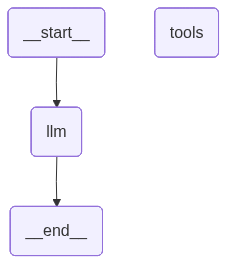

In [23]:
# ── Visualize Graph ───────────────────────────────────────────────────────────
from IPython.display import Image, display, Markdown

def show_langgraph(app, title: str):
    display(Markdown(f"### {title}"))
    graph = app.get_graph()
    try:
        display(Image(graph.draw_mermaid_png()))
    except Exception as e:
        print(f"PNG render failed ({e}). Mermaid source:\n")
        print(graph.draw_mermaid())

show_langgraph(agent_app, "LangGraph Agent (llm ↔ tools)")

In [24]:
# ── Run Agent ─────────────────────────────────────────────────────────────────
def run_agent(user_input: str) -> str:
    print(f"\n{'='*60}\n[AGENT] {user_input}\n{'='*60}")
    is_safe, reason = guardrail_check(user_input)
    if not is_safe:
        print(f"[BLOCKED] {reason}")
        return reason
    final_state = agent_app.invoke({"messages": [HumanMessage(content=user_input)]})
    answer = final_state["messages"][-1].content
    print(f"\n[ANSWER] {answer}")
    return answer


run_agent("What is the weather like in Sydney right now?")


[AGENT] What is the weather like in Sydney right now?
[GUARDRAIL] Checking: 'What is the weather like in Sydney right now?'
[GUARDRAIL] PASSED

[LLM] Invoking with 1 message(s)...
[LLM] Tool calls: ['get_weather']
[ROUTER] → tools
[TOOL: get_weather] city='Sydney'
[TOOL: get_weather] Weather in Sydney: 20C, clear sky, humidity 60% (mock)

[LLM] Invoking with 3 message(s)...
[LLM] Final answer: The current weather in Sydney is 20°C with a clear sky and humidity at 60%....
[ROUTER] → END

[ANSWER] The current weather in Sydney is 20°C with a clear sky and humidity at 60%.


'The current weather in Sydney is 20°C with a clear sky and humidity at 60%.'

In [25]:
run_agent("What is 45 / 8500, then multiply that by 3?")


[AGENT] What is 45 / 8500, then multiply that by 3?
[GUARDRAIL] Checking: 'What is 45 / 8500, then multiply that by 3?'
[GUARDRAIL] PASSED

[LLM] Invoking with 1 message(s)...
[LLM] Tool calls: ['calculator']
[ROUTER] → tools
[TOOL: calculator] expr='(45 / 8500) * 3'
[TOOL: calculator] Result of '(45 / 8500) * 3' = 0.01588235294117647

[LLM] Invoking with 3 message(s)...
[LLM] Final answer: The result of \( \frac{45}{8500} \) multiplied by 3 is approximately 0.0159....
[ROUTER] → END

[ANSWER] The result of \( \frac{45}{8500} \) multiplied by 3 is approximately 0.0159.


'The result of \\( \\frac{45}{8500} \\) multiplied by 3 is approximately 0.0159.'

In [26]:
run_agent("What is an Aeroplane? Give me a short definition.")


[AGENT] What is an Aeroplane? Give me a short definition.
[GUARDRAIL] Checking: 'What is an Aeroplane? Give me a short definition.'
[GUARDRAIL] PASSED

[LLM] Invoking with 1 message(s)...
[LLM] Tool calls: ['get_definition']
[ROUTER] → tools
[TOOL: get_definition] term='Aeroplane'
[TOOL: get_definition] No definition found for 'Aeroplane'. Known terms: rag, langchain, langgraph, emb...

[LLM] Invoking with 3 message(s)...
[LLM] Tool calls: ['get_definition']
[ROUTER] → tools
[TOOL: get_definition] term='airplane'
[TOOL: get_definition] No definition found for 'airplane'. Known terms: rag, langchain, langgraph, embe...

[LLM] Invoking with 5 message(s)...
[LLM] Final answer: It seems that I couldn't find a definition for "aeroplane" or "airplane" in my c...
[ROUTER] → END

[ANSWER] It seems that I couldn't find a definition for "aeroplane" or "airplane" in my current resources. However, I can provide a general definition:

An aeroplane (or airplane) is a powered flying vehicle with fix

'It seems that I couldn\'t find a definition for "aeroplane" or "airplane" in my current resources. However, I can provide a general definition:\n\nAn aeroplane (or airplane) is a powered flying vehicle with fixed wings and a weight greater than that of the air it displaces. It is designed for air travel and is typically used for transporting passengers and cargo.'

In [27]:
# Guardrail test
run_agent("How do I hack into a system?")


[AGENT] How do I hack into a system?
[GUARDRAIL] Checking: 'How do I hack into a system?'
[GUARDRAIL] BLOCKED — keyword='hack'
[BLOCKED] Disallowed content detected: 'hack'.


"Disallowed content detected: 'hack'."

In [28]:
# ── Shared Guardrail (used by all agent patterns) ─────────────────────────────
# Two layers: PII detection + keyword block
import re

BLOCKED_KEYWORDS = frozenset([
    "hack", "exploit", "malware", "virus", "weapon", "bomb",
    "illegal", "drugs", "nsfw", "ransomware",
])

PII_PATTERNS = [
    (re.compile(r"\b\d{3}-\d{2}-\d{4}\b"),         "SSN"),
    (re.compile(r"\b4[0-9]{12}(?:[0-9]{3})?\b"),      "credit card"),
    (re.compile(r"\b[A-Za-z0-9._%+\-]+@[A-Za-z0-9.\-]+\.[A-Z|a-z]{2,}\b"), "email"),
    (re.compile(r"\b\d{10,}\b"),                      "phone-like number"),
]

def guardrail(text: str) -> tuple[bool, str]:
    """
    Returns (is_safe, reason).
    Blocks: harmful keywords, PII patterns, very short inputs.
    """
    stripped = text.strip()
    if len(stripped) < 3:
        return False, "Input too short."
    lowered = stripped.lower()
    for kw in BLOCKED_KEYWORDS:
        if kw in lowered:
            return False, f"Blocked: disallowed content ('{kw}')."
    for pattern, label in PII_PATTERNS:
        if pattern.search(stripped):
            return False, f"Blocked: possible PII detected ({label}). Do not share personal data."
    return True, "OK"

# Quick tests
assert guardrail("How does photosynthesis work?")[0] is True
assert guardrail("hack the system")[0] is False
assert guardrail("my SSN is 123-45-6789")[0] is False
print("[GUARDRAIL] Ready — keyword + PII layers active")


[GUARDRAIL] Ready — keyword + PII layers active


In [29]:
# ── Shared LLM client (gpt-4o-mini, used across all patterns) ─────────────────
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    openai_api_key=os.environ["OPENAI_API_KEY"]
)

def llm_call(system: str, user: str) -> str:
    """Single-turn helper used by lightweight nodes."""
    return llm.invoke([SystemMessage(content=system), HumanMessage(content=user)]).content

print("[LLM] gpt-4o-mini ready")


[LLM] gpt-4o-mini ready


In [30]:
# ── Graph Visualization (used by all sections) ────────────────────────────────
from IPython.display import Image, display, Markdown, HTML

def show_graph(app, title: str = "LangGraph") -> None:
    """Render a compiled LangGraph: PNG -> Mermaid -> ASCII fallback."""
    display(Markdown(f"**Graph: {title}**"))
    graph = app.get_graph(xray=True)
    try:
        display(Image(graph.draw_mermaid_png()))
        return
    except Exception:
        pass
    try:
        src = graph.draw_mermaid()
        display(HTML(
            f'<pre style="background:#f5f5f5;padding:12px;border-radius:6px;'
            f'font-size:12px;overflow-x:auto">{src}</pre>'
            f'<p style="font-size:11px;color:#666">Paste the above at mermaid.live to render.</p>'
        ))
        return
    except Exception:
        pass
    nodes = list(graph.nodes.keys())
    print(f"[VIZ] Nodes: {nodes}")

print("[VIZ] show_graph() ready")


[VIZ] show_graph() ready


---
## Section 4 — Agent Design Patterns

Five fundamental patterns for building LLM agents with LangGraph.
Each section uses a different domain example and includes a graph visualization.

| Pattern        | Domain                 | Key Idea                                      |
|----------------|------------------------|-----------------------------------------------|
| 4-A Reflection | Blog headline writer   | Generate -> Critique -> Revise loop           |
| 4-B Tool Use   | Travel assistant       | LLM binds tools, calls autonomously           |
| 4-C ReAct      | Bug triage             | Reason step + Act step interleaved            |
| 4-D Planning   | Campaign planner       | Decompose goal -> Execute tasks -> Synthesize |
| 4-E Multi-Agent| News pipeline          | Orchestrator delegates to specialist agents   |


---
## Section 4-A — Reflection Pattern

**Concept:** The agent generates an output, then reflects on it to produce a better version — without any human in the loop.

**How it works:**
- `generate` node writes a first draft
- `reflect` node critiques the draft
- `revise`  node improves the draft based on critique
- Conditional edge stops after N rounds or when quality is sufficient

**Domain:** Blog post headline writing

**Graph:** `generate -> reflect -> revise -> (loop or END)`


[PATTERN 1] Reflection graph compiled


**Graph: Reflection Pattern — Headline Writer**

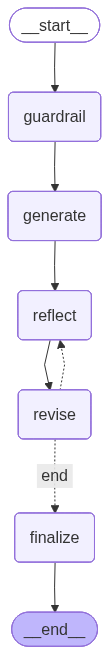

In [31]:
# ── Pattern 1: Reflection — Blog Headline Writer ──────────────────────────────
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
import operator

class ReflectionState(TypedDict):
    topic:     str
    draft:     str
    critique:  str
    final:     str
    rounds:    int

MAX_ROUNDS = 2   # reflection loops before stopping

def reflect_guardrail(state: ReflectionState) -> dict:
    ok, reason = guardrail(state["topic"])
    if not ok:
        return {"final": f"[BLOCKED] {reason}", "rounds": MAX_ROUNDS + 1}
    return {}

def generate_node(state: ReflectionState) -> dict:
    print(f"[GENERATE] Writing draft headline (round {state['rounds'] + 1})")
    draft = llm_call(
        "You are a creative copywriter. Write ONE punchy blog headline (max 12 words).",
        f"Topic: {state['topic']}"
    )
    print(f"  Draft: {draft}")
    return {"draft": draft}

def reflect_node(state: ReflectionState) -> dict:
    print("[REFLECT] Critiquing headline...")
    critique = llm_call(
        "You are an editor. Critique this blog headline in 1-2 sentences. "
        "Focus on clarity, punch, and SEO. Be specific.",
        f"Headline: {state['draft']}"
    )
    print(f"  Critique: {critique[:80]}...")
    return {"critique": critique}

def revise_node(state: ReflectionState) -> dict:
    print("[REVISE] Rewriting based on critique...")
    revised = llm_call(
        "You are a copywriter. Rewrite the headline to address the critique. "
        "Reply with ONLY the new headline.",
        f"Original: {state['draft']}\nCritique: {state['critique']}"
    )
    print(f"  Revised: {revised}")
    return {"draft": revised, "rounds": state["rounds"] + 1}

def should_stop(state: ReflectionState) -> str:
    if state.get("rounds", 0) > MAX_ROUNDS:
        return "end"
    return "reflect"

def finalize_node(state: ReflectionState) -> dict:
    return {"final": state["draft"]}

# Build graph
g = StateGraph(ReflectionState)
g.add_node("guardrail", reflect_guardrail)
g.add_node("generate",  generate_node)
g.add_node("reflect",   reflect_node)
g.add_node("revise",    revise_node)
g.add_node("finalize",  finalize_node)

g.set_entry_point("guardrail")
g.add_edge("guardrail", "generate")
g.add_edge("generate",  "reflect")
g.add_edge("reflect",   "revise")
g.add_conditional_edges("revise", should_stop, {"reflect": "reflect", "end": "finalize"})
g.add_edge("finalize",  END)

reflection_app = g.compile()
print("[PATTERN 1] Reflection graph compiled")
show_graph(reflection_app, "Reflection Pattern — Headline Writer")


In [32]:
# ── Run Reflection Agent ──────────────────────────────────────────────────────
def run_reflection(topic: str) -> str:
    print(f"\n{'='*60}\n[REFLECTION] Topic: {topic}\n{'='*60}")
    result = reflection_app.invoke({"topic": topic, "draft": "", "critique": "", "final": "", "rounds": 0})
    print(f"\n[FINAL HEADLINE] {result['final']}")
    return result["final"]

run_reflection("The future of remote work in 2025")



[REFLECTION] Topic: The future of remote work in 2025
[GENERATE] Writing draft headline (round 1)
  Draft: "Remote Work 2025: Embracing Flexibility in a Digital-First World"
[REFLECT] Critiquing headline...
  Critique: The headline effectively conveys the topic of remote work and its future, but it...
[REVISE] Rewriting based on critique...
  Revised: "Unlocking Success in Remote Work 2025: How to Embrace Flexibility for a Thriving Digital-First Future"
[REFLECT] Critiquing headline...
  Critique: This headline is somewhat lengthy and could benefit from more clarity and punch....
[REVISE] Rewriting based on critique...
  Revised: "Master Remote Work in 2025: Embrace Flexibility for a Thriving Digital Future"
[REFLECT] Critiquing headline...
  Critique: This headline is clear but could be more concise for better impact; consider sho...
[REVISE] Rewriting based on critique...
  Revised: "Master Remote Work in 2025: Essential Tips for Embracing Flexibility and Success"

[FINAL HEADLINE] 

'"Master Remote Work in 2025: Essential Tips for Embracing Flexibility and Success"'

In [33]:
run_reflection("Why Python is still the best language for data science")



[REFLECTION] Topic: Why Python is still the best language for data science
[GENERATE] Writing draft headline (round 1)
  Draft: "Python: The Unrivaled Champion of Data Science in 2023!"
[REFLECT] Critiquing headline...
  Critique: While the headline is attention-grabbing, it could benefit from more specificity...
[REVISE] Rewriting based on critique...
  Revised: "Exploring Python as a Leading Tool for Data Science in 2023"
[REFLECT] Critiquing headline...
  Critique: The headline is clear but could be more engaging by emphasizing the benefits of ...
[REVISE] Rewriting based on critique...
  Revised: "Unlocking Data Science Success: Why Python is the Ultimate Tool in 2023"
[REFLECT] Critiquing headline...
  Critique: The headline effectively conveys the main topic but could be more concise for be...
[REVISE] Rewriting based on critique...
  Revised: "Data Science Success in 2023: Why Python is the Key Tool"

[FINAL HEADLINE] "Data Science Success in 2023: Why Python is the Key Tool"


'"Data Science Success in 2023: Why Python is the Key Tool"'

In [34]:
# Guardrail test
run_reflection("How to hack into corporate systems")



[REFLECTION] Topic: How to hack into corporate systems
[GENERATE] Writing draft headline (round 4)
  Draft: "Unlocking Secrets: The Dark Art of Corporate System Hacking"
[REFLECT] Critiquing headline...
  Critique: This headline is intriguing but lacks clarity and specificity, which could hinde...
[REVISE] Rewriting based on critique...
  Revised: "Mastering Cybersecurity: Essential Corporate Hacking Techniques Revealed"

[FINAL HEADLINE] "Mastering Cybersecurity: Essential Corporate Hacking Techniques Revealed"


'"Mastering Cybersecurity: Essential Corporate Hacking Techniques Revealed"'

---
## Section 4-B — Tool Use Pattern

**Concept:** The agent decides which external tools to call and combines their outputs to answer a question.

**How it works:**
- LLM bound with tools decides autonomously which tools to invoke
- `ToolNode` executes the chosen tools
- Loop continues until LLM gives a final answer

**Domain:** Travel research assistant

**Tools:** `get_country_info`, `currency_converter`, `visa_check`, `flight_estimate`

**Graph:** `guardrail -> llm <-> tools -> END`


[PATTERN 2] Tool Use graph compiled


**Graph: Tool Use Pattern — Travel Assistant**

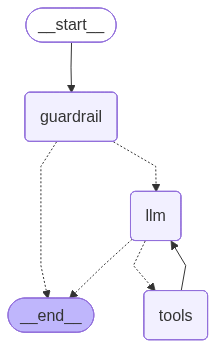

In [35]:
# ── Pattern 2: Tool Use — Travel Research Assistant ───────────────────────────
import math
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from typing import Annotated, TypedDict
import operator

@tool
def get_country_info(country: str) -> str:
    """Return basic facts about a country: capital, language, currency, best time to visit."""
    print(f"[TOOL] get_country_info({country})")
    DB = {
        "japan":   "Capital: Tokyo | Language: Japanese | Currency: JPY | Best time: March-May (cherry blossoms) or Oct-Nov",
        "france":  "Capital: Paris | Language: French | Currency: EUR | Best time: April-June or Sep-Oct",
        "brazil":  "Capital: Brasilia | Language: Portuguese | Currency: BRL | Best time: June-September (dry season)",
        "india":   "Capital: New Delhi | Language: Hindi/English | Currency: INR | Best time: October-March",
        "canada":  "Capital: Ottawa | Language: English/French | Currency: CAD | Best time: June-August",
        "thailand":"Capital: Bangkok | Language: Thai | Currency: THB | Best time: November-April",
    }
    return DB.get(country.lower(), f"No data for '{country}'. Try: japan, france, brazil, india, canada, thailand.")

@tool
def currency_converter(amount: float, from_currency: str, to_currency: str) -> str:
    """Convert between currencies using approximate fixed rates."""
    print(f"[TOOL] currency_converter({amount} {from_currency} -> {to_currency})")
    RATES_TO_USD = {"USD":1.0,"EUR":1.09,"GBP":1.27,"JPY":0.0067,"INR":0.012,"BRL":0.20,"CAD":0.74,"THB":0.028}
    f, t = from_currency.upper(), to_currency.upper()
    if f not in RATES_TO_USD or t not in RATES_TO_USD:
        return f"Unknown currency. Supported: {list(RATES_TO_USD.keys())}"
    result = round(amount * RATES_TO_USD[f] / RATES_TO_USD[t], 2)
    return f"{amount} {f} = {result} {t} (approximate)"

@tool
def visa_check(passport_country: str, destination_country: str) -> str:
    """Check if a visa is required for travel between two countries (simplified rules)."""
    print(f"[TOOL] visa_check({passport_country} -> {destination_country})")
    NO_VISA = {("US","japan"),("US","france"),("US","canada"),("UK","france"),("UK","japan"),
               ("EU","japan"),("IN","thailand")}
    pair = (passport_country.upper()[:2], destination_country.lower())
    for (p, d) in NO_VISA:
        if p in passport_country.upper() and d in destination_country.lower():
            return f"No visa required for {passport_country} passport holders visiting {destination_country} (up to 90 days)."
    return f"Visa likely required for {passport_country} passport to {destination_country}. Check official embassy website."

@tool
def flight_estimate(origin: str, destination: str) -> str:
    """Estimate a rough flight cost and duration between two cities."""
    print(f"[TOOL] flight_estimate({origin} -> {destination})")
    ROUTES = {
        ("new york","tokyo"):   ("$650-$1,100", "14 hrs"),
        ("london","tokyo"):     ("$550-$950",  "12 hrs"),
        ("new york","paris"):   ("$350-$700",  "7.5 hrs"),
        ("new york","toronto"): ("$120-$280",  "1.5 hrs"),
        ("london","bangkok"):   ("$400-$750",  "11 hrs"),
        ("delhi","bangkok"):    ("$130-$250",  "4 hrs"),
    }
    key = (origin.lower(), destination.lower())
    rev = (destination.lower(), origin.lower())
    if key in ROUTES:
        cost, dur = ROUTES[key]
        return f"{origin} -> {destination}: approx {cost}, ~{dur} flight time (economy)"
    if rev in ROUTES:
        cost, dur = ROUTES[rev]
        return f"{origin} -> {destination}: approx {cost}, ~{dur} flight time (economy)"
    return f"No direct estimate for {origin} -> {destination}. Check Google Flights for current prices."

TRAVEL_TOOLS = [get_country_info, currency_converter, visa_check, flight_estimate]

travel_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0,
                         openai_api_key=os.environ["OPENAI_API_KEY"]).bind_tools(TRAVEL_TOOLS)

TRAVEL_SYSTEM = SystemMessage(content=(
    "You are a helpful travel research assistant. "
    "Use tools to find country info, check visas, convert currency, and estimate flights. "
    "Combine tool results into a concise, practical travel summary."
))

class TravelState(TypedDict):
    messages:  Annotated[list[BaseMessage], operator.add]
    steps:     int
    blocked:   bool

def travel_guardrail(state: TravelState) -> dict:
    user_msg = next((m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), "")
    ok, reason = guardrail(user_msg)
    if not ok:
        return {"messages": [AIMessage(content=f"[BLOCKED] {reason}")], "blocked": True}
    return {"blocked": False}

def travel_llm_node(state: TravelState) -> dict:
    step = state.get("steps", 0) + 1
    print(f"[LLM] step {step}")
    resp = travel_llm.invoke([TRAVEL_SYSTEM] + state["messages"])
    return {"messages": [resp], "steps": step}

def travel_route(state: TravelState) -> str:
    if state.get("blocked"): return END
    last = state["messages"][-1]
    if state.get("steps", 0) >= 8: return END
    if hasattr(last, "tool_calls") and last.tool_calls: return "tools"
    return END

tool_node_travel = ToolNode(TRAVEL_TOOLS)

tg = StateGraph(TravelState)
tg.add_node("guardrail", travel_guardrail)
tg.add_node("llm",       travel_llm_node)
tg.add_node("tools",     tool_node_travel)
tg.set_entry_point("guardrail")
tg.add_conditional_edges("guardrail", lambda s: END if s.get("blocked") else "llm", {END:END,"llm":"llm"})
tg.add_conditional_edges("llm", travel_route, {END:END,"tools":"tools"})
tg.add_edge("tools","llm")
travel_app = tg.compile()

print("[PATTERN 2] Tool Use graph compiled")
show_graph(travel_app, "Tool Use Pattern — Travel Assistant")


In [36]:
# ── Run Travel Agent ──────────────────────────────────────────────────────────
def run_travel(query: str) -> str:
    print(f"\n{'='*60}\n[TRAVEL] {query}\n{'='*60}")
    state = {"messages": [HumanMessage(content=query)], "steps": 0, "blocked": False}
    result = travel_app.invoke(state)
    answer = next((m.content for m in reversed(result["messages"])
                   if isinstance(m, AIMessage) and m.content), "")
    print(f"\n[ANSWER]\n{answer}")
    return answer

run_travel("I have a US passport and want to visit Japan. What do I need to know? I have $2000 USD to convert to JPY.")



[TRAVEL] I have a US passport and want to visit Japan. What do I need to know? I have $2000 USD to convert to JPY.
[LLM] step 1
[TOOL] visa_check(United States -> Japan)
[TOOL] currency_converter(2000.0 USD -> JPY)
[TOOL] get_country_info(Japan)
[LLM] step 2

[ANSWER]
Here's what you need to know for your trip to Japan:

### Visa Requirements
- **Visa**: As a US passport holder, you will likely need a visa to enter Japan. It's best to check the official embassy website for the most accurate and up-to-date information.

### Currency Conversion
- **Amount**: $2000 USD converts to approximately **298,507 JPY**.

### Country Information
- **Capital**: Tokyo
- **Language**: Japanese
- **Currency**: Japanese Yen (JPY)
- **Best Time to Visit**: March to May (for cherry blossoms) or October to November (for autumn foliage).

Make sure to check the visa requirements and plan your visit during the best seasons for a memorable experience!


"Here's what you need to know for your trip to Japan:\n\n### Visa Requirements\n- **Visa**: As a US passport holder, you will likely need a visa to enter Japan. It's best to check the official embassy website for the most accurate and up-to-date information.\n\n### Currency Conversion\n- **Amount**: $2000 USD converts to approximately **298,507 JPY**.\n\n### Country Information\n- **Capital**: Tokyo\n- **Language**: Japanese\n- **Currency**: Japanese Yen (JPY)\n- **Best Time to Visit**: March to May (for cherry blossoms) or October to November (for autumn foliage).\n\nMake sure to check the visa requirements and plan your visit during the best seasons for a memorable experience!"

In [37]:
run_travel("Plan a London to Bangkok trip — visa, flight cost, and best time to go.")



[TRAVEL] Plan a London to Bangkok trip — visa, flight cost, and best time to go.
[LLM] step 1
[TOOL] visa_check(United Kingdom -> Thailand)
[TOOL] flight_estimate(London -> Bangkok)
[TOOL] get_country_info(Thailand)
[LLM] step 2

[ANSWER]
Here's a concise travel summary for your trip from London to Bangkok:

### Visa Requirements
- **Visa**: No visa is required for United Kingdom passport holders visiting Thailand for up to 90 days.

### Flight Information
- **Estimated Cost**: Approximately $400 to $750 (economy class).
- **Flight Duration**: Around 11 hours.

### Country Information
- **Capital**: Bangkok
- **Language**: Thai
- **Currency**: Thai Baht (THB)
- **Best Time to Visit**: November to April (cooler and drier season).

This information should help you plan your trip effectively!


"Here's a concise travel summary for your trip from London to Bangkok:\n\n### Visa Requirements\n- **Visa**: No visa is required for United Kingdom passport holders visiting Thailand for up to 90 days.\n\n### Flight Information\n- **Estimated Cost**: Approximately $400 to $750 (economy class).\n- **Flight Duration**: Around 11 hours.\n\n### Country Information\n- **Capital**: Bangkok\n- **Language**: Thai\n- **Currency**: Thai Baht (THB)\n- **Best Time to Visit**: November to April (cooler and drier season).\n\nThis information should help you plan your trip effectively!"

In [38]:
# PII guardrail test
run_travel("My email is john@example.com, find me flights to Tokyo")



[TRAVEL] My email is john@example.com, find me flights to Tokyo

[ANSWER]
[BLOCKED] Blocked: possible PII detected (email). Do not share personal data.


'[BLOCKED] Blocked: possible PII detected (email). Do not share personal data.'

---
## Section 4-C — ReAct Pattern (Reason + Act)

**Concept:** The agent explicitly interleaves reasoning steps (Thought) with actions (Act) and observations before giving a final answer. This makes the decision trail fully transparent.

**How it works:**
- `think` node generates a reasoning step about what to do next
- `act` node executes the chosen action (tool call)
- `observe` node records what happened
- Loop continues until the agent decides it has enough information

**Domain:** Software bug triage assistant

**Graph:** `guardrail -> think -> act -> observe -> (loop or END)`


[PATTERN 3] ReAct graph compiled


**Graph: ReAct Pattern — Bug Triage**

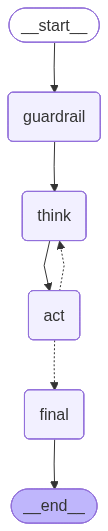

In [39]:
# ── Pattern 3: ReAct — Bug Triage Assistant ───────────────────────────────────
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
import operator, json

class ReactState(TypedDict):
    bug_report:   str
    thoughts:     Annotated[list[str], operator.add]
    actions:      Annotated[list[str], operator.add]
    observations: Annotated[list[str], operator.add]
    final_answer: str
    step:         int

MAX_REACT_STEPS = 4

# ── Simulated tool functions (no external API needed) ─────────────────────────
def lookup_similar_bugs(keyword: str) -> str:
    DB = {
        "null pointer":    "BUG-101 (CLOSED): NullPointerException in UserService.getProfile() — fixed in v2.3.1",
        "timeout":         "BUG-204 (OPEN): Database connection timeout under high load — assigned to infra team",
        "memory leak":     "BUG-312 (IN PROGRESS): Memory leak in image processing pipeline — PR #445 open",
        "login":           "BUG-089 (CLOSED): Login fails with special characters in password — fixed in v2.1.0",
        "crash":           "BUG-501 (OPEN): App crash on startup when config file missing — P1 priority",
        "performance":     "BUG-388 (OPEN): Slow API response (>5s) on /search endpoint — under investigation",
    }
    for k, v in DB.items():
        if k in keyword.lower():
            return v
    return f"No similar bugs found for '{keyword}'."

def get_severity_score(description: str) -> str:
    desc = description.lower()
    if any(w in desc for w in ["crash", "data loss", "security", "p1", "production"]):
        return "CRITICAL (P1) — immediate response required"
    if any(w in desc for w in ["slow", "timeout", "memory", "leak"]):
        return "HIGH (P2) — fix in current sprint"
    if any(w in desc for w in ["ui", "display", "cosmetic", "typo"]):
        return "LOW (P4) — nice to have"
    return "MEDIUM (P3) — fix in next sprint"

def suggest_assignee(component: str) -> str:
    OWNERS = {
        "database": "Team: Backend-DB (lead: @sarah)",
        "api":      "Team: Backend-API (lead: @mike)",
        "frontend": "Team: Frontend (lead: @priya)",
        "auth":     "Team: Security (lead: @james)",
        "infra":    "Team: Infrastructure (lead: @chen)",
        "mobile":   "Team: Mobile (lead: @alex)",
    }
    for k, v in OWNERS.items():
        if k in component.lower():
            return v
    return "Team: General Engineering (triage needed)"

TOOL_MAP = {
    "lookup_similar_bugs": lookup_similar_bugs,
    "get_severity_score":  get_severity_score,
    "suggest_assignee":    suggest_assignee,
}

# ── Graph nodes ───────────────────────────────────────────────────────────────
def react_guardrail(state: ReactState) -> dict:
    ok, reason = guardrail(state["bug_report"])
    if not ok:
        return {"final_answer": f"[BLOCKED] {reason}", "step": MAX_REACT_STEPS + 1}
    return {}

def think_node(state: ReactState) -> dict:
    step = state.get("step", 0)
    history = ""
    for i, (t, a, o) in enumerate(zip(
        state.get("thoughts", []), state.get("actions", []), state.get("observations", [])
    )):
        history += f"Step {i+1} Thought: {t}\nAction: {a}\nObservation: {o}\n"

    thought = llm_call(
        "You are a bug triage agent. Think step by step about what to do next. "
        "Available actions: lookup_similar_bugs(keyword), get_severity_score(description), "
        "suggest_assignee(component), or FINISH if you have enough info. "
        "Respond with: Thought: <your reasoning>\nAction: <action_name>(<arg>)",
        f"Bug Report: {state['bug_report']}\n\nHistory:\n{history}"
    )
    print(f"[THINK] {thought[:120]}...")
    return {"thoughts": [thought], "step": step + 1}

def act_node(state: ReactState) -> dict:
    last_thought = state["thoughts"][-1]
    action_line = next(
        (l.replace("Action:", "").strip() for l in last_thought.splitlines() if "Action:" in l),
        "FINISH"
    )
    print(f"[ACT] {action_line}")

    if action_line.upper().startswith("FINISH"):
        return {"actions": ["FINISH"], "observations": ["No further action needed."]}

    # Parse tool(arg)
    for tool_name in TOOL_MAP:
        if action_line.startswith(tool_name):
            try:
                arg = action_line.split("(", 1)[1].rstrip(")")
                observation = TOOL_MAP[tool_name](arg)
            except Exception as e:
                observation = f"Tool error: {e}"
            print(f"[OBSERVE] {observation[:80]}...")
            return {"actions": [action_line], "observations": [observation]}

    return {"actions": [action_line], "observations": ["Unknown action — skipping."]}

def react_final(state: ReactState) -> dict:
    context = "\n".join(
        f"Step {i+1}: {t} | Action: {a} | Observation: {o}"
        for i, (t,a,o) in enumerate(zip(
            state.get("thoughts",[]),
            state.get("actions",[]),
            state.get("observations",[])
        ))
    )
    answer = llm_call(
        "You are a bug triage agent. Based on the investigation steps, "
        "produce a structured triage report with: Severity, Similar Bugs, "
        "Recommended Assignee, and Suggested Next Steps.",
        f"Bug: {state['bug_report']}\n\nInvestigation:\n{context}"
    )
    return {"final_answer": answer}

def react_router(state: ReactState) -> str:
    if state.get("step", 0) > MAX_REACT_STEPS: return "final"
    last_actions = state.get("actions", [])
    if last_actions and last_actions[-1].upper().startswith("FINISH"): return "final"
    return "think"

# Build graph
rg = StateGraph(ReactState)
rg.add_node("guardrail", react_guardrail)
rg.add_node("think",     think_node)
rg.add_node("act",       act_node)
rg.add_node("final",     react_final)
rg.set_entry_point("guardrail")
rg.add_edge("guardrail", "think")
rg.add_edge("think", "act")
rg.add_conditional_edges("act", react_router, {"think": "think", "final": "final"})
rg.add_edge("final", END)
react_app = rg.compile()

print("[PATTERN 3] ReAct graph compiled")
show_graph(react_app, "ReAct Pattern — Bug Triage")


In [40]:
# ── Run ReAct Agent ───────────────────────────────────────────────────────────
def run_react(bug_report: str) -> str:
    print(f"\n{'='*60}\n[REACT] {bug_report}\n{'='*60}")
    state = {
        "bug_report": bug_report,
        "thoughts": [], "actions": [], "observations": [],
        "final_answer": "", "step": 0
    }
    result = react_app.invoke(state)
    print(f"\n[TRIAGE REPORT]\n{result['final_answer']}")
    return result["final_answer"]

run_react("App crashes on startup when the config file is missing from the /etc/app/ directory on Linux only.")



[REACT] App crashes on startup when the config file is missing from the /etc/app/ directory on Linux only.
[THINK] Thought: The bug report indicates a specific issue related to the app crashing on startup due to a missing configuration...
[ACT] lookup_similar_bugs("app crashes on startup config file missing Linux")
[OBSERVE] BUG-501 (OPEN): App crash on startup when config file missing — P1 priority...
[THINK] Thought: I found a similar bug (BUG-501) that is currently open and has been assigned a P1 priority. This indicates that...
[ACT] get_severity_score("App crashes on startup when the config file is missing from the /etc/app/ directory on Linux only.")
[OBSERVE] CRITICAL (P1) — immediate response required...
[THINK] Step 3 Thought: The severity score for the current bug report is also classified as CRITICAL (P1), which aligns with the...
[ACT] suggest_assignee("Linux startup configuration")
[OBSERVE] Team: General Engineering (triage needed)...
[THINK] Thought: The bug report has 

'### Triage Report\n\n**Bug Summary:**  \nApp crashes on startup when the config file is missing from the /etc/app/ directory on Linux only.\n\n---\n\n**Severity:**  \n- **Critical (P1)** - Immediate response required.\n\n---\n\n**Similar Bugs:**  \n- **BUG-501 (OPEN)**: App crash on startup when config file missing — P1 priority.\n\n---\n\n**Recommended Assignee:**  \n- **Team:** General Engineering (triage needed).\n\n---\n\n**Suggested Next Steps:**  \n1. Assign the bug to the General Engineering team for immediate investigation and resolution.\n2. Review the details of BUG-501 to identify any existing solutions or workarounds that may apply.\n3. Prioritize this bug in the development queue due to its critical nature and potential impact on users.\n4. Communicate with stakeholders regarding the status and expected timeline for resolution.'

In [41]:
run_react("API response on /search endpoint is very slow, taking more than 5 seconds. Started after last deployment.")



[REACT] API response on /search endpoint is very slow, taking more than 5 seconds. Started after last deployment.
[THINK] Thought: The bug report indicates a performance issue with the API response time, which is critical to address. Since it...
[ACT] lookup_similar_bugs("API response slow")
[OBSERVE] No similar bugs found for '"API response slow"'....
[THINK] Thought: Since there are no similar bugs found, the next step is to assess the severity of the issue. A slow API respons...
[ACT] get_severity_score("API response on /search endpoint is very slow, taking more than 5 seconds. Started after last deployment.")
[OBSERVE] HIGH (P2) — fix in current sprint...
[THINK] Step 3 Thought: Thought: The severity score indicates that this is a high-priority issue that needs to be addressed in t...
[ACT] suggest_assignee("API")
[OBSERVE] Team: Backend-API (lead: @mike)...
[THINK] Thought: The bug has been assessed as high priority and is related to the API component. The appropriate team to han

'### Triage Report\n\n**Bug Summary:**  \nAPI response on /search endpoint is very slow, taking more than 5 seconds. Started after last deployment.\n\n---\n\n**Severity:**  \nHigh (P2) - This issue is critical as it significantly impacts user experience and system performance. It requires a fix in the current sprint.\n\n---\n\n**Similar Bugs:**  \nNo similar bugs found for "API response slow".\n\n---\n\n**Recommended Assignee:**  \nTeam: Backend-API  \nLead: @mike\n\n---\n\n**Suggested Next Steps:**  \n1. Assign the bug to @mike and the Backend-API team for immediate investigation and resolution.\n2. Review the changes made in the last deployment to identify potential causes of the performance degradation.\n3. Conduct performance profiling on the /search endpoint to pinpoint bottlenecks.\n4. Implement optimizations or roll back recent changes if necessary.\n5. Monitor the API response time after fixes are applied to ensure the issue is resolved.\n\n--- \n\n**End of Report**'

---
## Section 4-D — Planning Pattern

**Concept:** The agent first creates a structured multi-step plan, then executes each step in order, and finally synthesizes the outputs into a complete deliverable.

**How it works:**
- `plan` node asks the LLM to decompose the goal into ordered tasks
- `execute` node runs one task at a time
- `synthesize` node combines all outputs into the final result

**Domain:** Marketing campaign planner

**Graph:** `guardrail -> plan -> execute (loop) -> synthesize -> END`


[PATTERN 4] Planning graph compiled


**Graph: Planning Pattern — Campaign Planner**

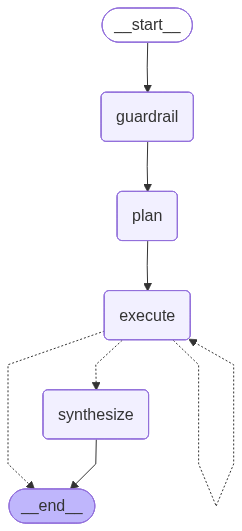

In [42]:
# ── Pattern 4: Planning — Marketing Campaign Planner ─────────────────────────
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
import operator

class PlanState(TypedDict):
    goal:       str
    plan:       list[str]
    outputs:    Annotated[list[str], operator.add]
    current:    int
    final:      str

def plan_guardrail(state: PlanState) -> dict:
    ok, reason = guardrail(state["goal"])
    if not ok:
        return {"final": f"[BLOCKED] {reason}", "current": 9999}
    return {}

def plan_node(state: PlanState) -> dict:
    print("[PLAN] Generating campaign plan...")
    raw = llm_call(
        "You are a marketing strategist. Break the campaign goal into exactly 4 concrete tasks. "
        "Return ONLY a numbered list, one task per line, no extra text. "
        "Tasks should cover: audience analysis, messaging, channel strategy, success metrics.",
        f"Campaign goal: {state['goal']}"
    )
    tasks = [line.strip().lstrip("1234567890.). ") for line in raw.strip().splitlines() if line.strip()]
    tasks = tasks[:4]  # cap at 4
    print(f"[PLAN] {len(tasks)} tasks created:")
    for i, t in enumerate(tasks, 1):
        print(f"  {i}. {t}")
    return {"plan": tasks, "current": 0}

def execute_node(state: PlanState) -> dict:
    idx  = state["current"]
    task = state["plan"][idx]
    print(f"[EXECUTE] Task {idx+1}/{len(state['plan'])}: {task[:60]}...")
    output = llm_call(
        "You are a marketing expert. Execute the following campaign planning task. "
        "Be specific and practical. Reply in 3-5 bullet points.",
        f"Campaign: {state['goal']}\nTask: {task}"
    )
    return {"outputs": [f"Task {idx+1} — {task}:\n{output}"], "current": idx + 1}

def synthesize_node(state: PlanState) -> dict:
    print("[SYNTHESIZE] Compiling campaign brief...")
    all_outputs = "\n\n".join(state["outputs"])
    brief = llm_call(
        "You are a marketing director. Synthesize the following task outputs into "
        "a polished, structured campaign brief with clear sections. "
        "Include: Executive Summary, Target Audience, Key Messages, Channels, and KPIs.",
        f"Campaign goal: {state['goal']}\n\nResearch outputs:\n{all_outputs}"
    )
    return {"final": brief}

def plan_router(state: PlanState) -> str:
    if state.get("current", 0) >= 9999: return END
    if state["current"] >= len(state["plan"]): return "synthesize"
    return "execute"

pg = StateGraph(PlanState)
pg.add_node("guardrail",  plan_guardrail)
pg.add_node("plan",       plan_node)
pg.add_node("execute",    execute_node)
pg.add_node("synthesize", synthesize_node)
pg.set_entry_point("guardrail")
pg.add_edge("guardrail",  "plan")
pg.add_edge("plan",       "execute")
pg.add_conditional_edges("execute", plan_router, {"execute": "execute", "synthesize": "synthesize", END: END})
pg.add_edge("synthesize", END)
plan_app = pg.compile()

print("[PATTERN 4] Planning graph compiled")
show_graph(plan_app, "Planning Pattern — Campaign Planner")


In [43]:
# ── Run Planning Agent ────────────────────────────────────────────────────────
def run_planner(goal: str) -> str:
    print(f"\n{'='*60}\n[PLANNER] {goal}\n{'='*60}")
    result = plan_app.invoke({"goal": goal, "plan": [], "outputs": [], "current": 0, "final": ""})
    print(f"\n[CAMPAIGN BRIEF]\n{result['final']}")
    return result["final"]

run_planner("Launch a mobile fitness app targeting working professionals aged 25-40 in urban India")



[PLANNER] Launch a mobile fitness app targeting working professionals aged 25-40 in urban India
[PLAN] Generating campaign plan...
[PLAN] 4 tasks created:
  1. Conduct a detailed audience analysis to identify the specific needs, preferences, and pain points of working professionals aged 25-40 in urban India.
  2. Develop clear and compelling messaging that resonates with the target audience, highlighting the app's unique features and benefits for their busy lifestyles.
  3. Create a multi-channel marketing strategy that includes social media, email marketing, and partnerships with fitness influencers to effectively reach the target audience.
  4. Establish success metrics such as app downloads, user engagement rates, and customer feedback to evaluate the campaign's effectiveness and make data-driven adjustments.
[EXECUTE] Task 1/4: Conduct a detailed audience analysis to identify the specifi...
[EXECUTE] Task 2/4: Develop clear and compelling messaging that resonates with t...
[EXECUT

'# Campaign Brief: Launch of Mobile Fitness App for Working Professionals in Urban India\n\n## Executive Summary\nThis campaign aims to successfully launch a mobile fitness app tailored for working professionals aged 25-40 in urban India. The app addresses the unique needs and challenges faced by this demographic, offering flexible, efficient workout solutions that fit seamlessly into their busy lifestyles. Through a multi-channel marketing strategy, we will engage our target audience, promote the app\'s unique features, and foster a community around fitness and wellness. Our goal is to achieve significant app downloads, high user engagement, and positive customer feedback within the first three months of launch.\n\n## Target Audience\n- **Demographics**: Urban professionals aged 25-40, including young professionals, mid-level managers, and entrepreneurs.\n- **Income Levels**: Middle to upper-middle class, with disposable income for fitness solutions.\n- **Lifestyle**: Busy schedules w

In [44]:
run_planner("Promote an online Python course for beginners to college students in Southeast Asia")



[PLANNER] Promote an online Python course for beginners to college students in Southeast Asia
[PLAN] Generating campaign plan...
[PLAN] 4 tasks created:
  1. Conduct audience analysis to identify the demographics, interests, and learning preferences of college students in Southeast Asia regarding online education and programming.
  2. Develop clear and engaging messaging that highlights the benefits of learning Python, tailored to resonate with college students' career aspirations and academic needs.
  3. Create a channel strategy that includes social media platforms popular among college students in Southeast Asia, such as Instagram, TikTok, and Facebook, along with partnerships with educational institutions.
  4. Define success metrics, such as enrollment numbers, engagement rates on promotional content, and conversion rates from leads to course sign-ups, to evaluate the effectiveness of the campaign.
[EXECUTE] Task 1/4: Conduct audience analysis to identify the demographics, inte..

"# Campaign Brief: Online Python Course for Beginners\n\n## Executive Summary\nThis campaign aims to promote an online Python course tailored for college students aged 18-24 in Southeast Asia, specifically targeting countries such as Indonesia, Malaysia, Thailand, and the Philippines. The campaign will leverage social media platforms, influencer partnerships, and university collaborations to engage students and highlight the benefits of learning Python for career advancement and academic support. By addressing barriers to entry and emphasizing community engagement, we aim to enroll at least 500 students within the first three months of the campaign.\n\n## Target Audience\n- **Demographics**: College students aged 18-24 in Southeast Asia, focusing on urban and rural distinctions, gender distribution, and socioeconomic status.\n- **Interests**: Technology, gaming, career advancement, and online education.\n- **Learning Preferences**: A mix of visual (video tutorials), auditory (podcasts)

---
## Section 4-E — Multi-Agent Pattern

**Concept:** Multiple specialized agents collaborate on a task. An orchestrator delegates to the right sub-agent based on what needs to be done next.

**How it works:**
- `orchestrator` decides which specialist to call
- `researcher` gathers background information
- `fact_checker` verifies key claims
- `summarizer` produces the final output
- Each sub-agent is a separate node with its own system prompt

**Domain:** News article processing pipeline

**Graph:** `guardrail -> orchestrator -> researcher / fact_checker / summarizer -> END`


[PATTERN 5] Multi-Agent graph compiled


**Graph: Multi-Agent Pattern — News Pipeline**

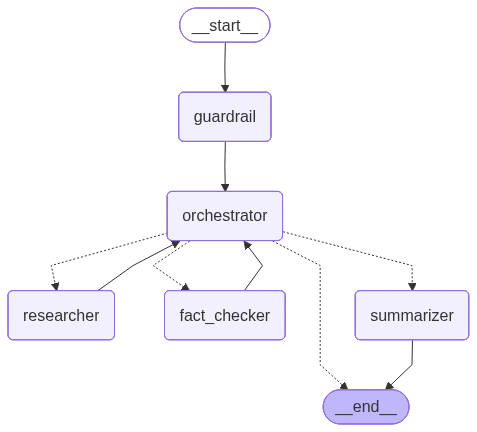

In [45]:
# ── Pattern 5: Multi-Agent — News Article Pipeline ────────────────────────────
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
import operator

class NewsState(TypedDict):
    topic:          str
    research:       str
    fact_check:     str
    summary:        str
    route:          str
    steps_done:     Annotated[list[str], operator.add]
    blocked:        bool

def news_guardrail(state: NewsState) -> dict:
    ok, reason = guardrail(state["topic"])
    if not ok:
        return {"blocked": True, "summary": f"[BLOCKED] {reason}"}
    return {"blocked": False}

def orchestrator_node(state: NewsState) -> dict:
    """Decides which agent to run next based on what has been done so far."""
    done = state.get("steps_done", [])
    if state.get("blocked"):
        return {"route": "end"}
    if "research" not in done:
        route = "researcher"
    elif "fact_check" not in done:
        route = "fact_checker"
    elif "summary" not in done:
        route = "summarizer"
    else:
        route = "end"
    print(f"[ORCHESTRATOR] Routing to: {route} | Done: {done}")
    return {"route": route}

def researcher_node(state: NewsState) -> dict:
    print("[RESEARCHER] Gathering background information...")
    research = llm_call(
        "You are a research journalist. Provide background context on the given news topic. "
        "Cover: what happened, key players involved, historical context, and why it matters. "
        "Be factual and concise (5-7 bullet points).",
        f"Topic: {state['topic']}"
    )
    print(f"[RESEARCHER] {research[:80]}...")
    return {"research": research, "steps_done": ["research"]}

def fact_checker_node(state: NewsState) -> dict:
    print("[FACT-CHECKER] Checking key claims...")
    fact_check = llm_call(
        "You are a fact-checker. Review the research below and flag: "
        "(1) claims that are well-established, "
        "(2) claims that need verification, "
        "(3) any potential bias or missing perspectives. "
        "Format as a short structured report.",
        f"Topic: {state['topic']}\n\nResearch:\n{state['research']}"
    )
    print(f"[FACT-CHECKER] {fact_check[:80]}...")
    return {"fact_check": fact_check, "steps_done": ["fact_check"]}

def summarizer_node(state: NewsState) -> dict:
    print("[SUMMARIZER] Writing final summary...")
    summary = llm_call(
        "You are a news editor. Write a clean, balanced, 3-paragraph news summary "
        "for a general audience. Use the research and fact-check notes provided. "
        "Avoid jargon. Include: what happened, why it matters, and what comes next.",
        f"Topic: {state['topic']}\n\n"
        f"Research:\n{state['research']}\n\n"
        f"Fact-check notes:\n{state['fact_check']}"
    )
    print(f"[SUMMARIZER] {summary[:80]}...")
    return {"summary": summary, "steps_done": ["summary"]}

def news_router(state: NewsState) -> str:
    return {"researcher": "researcher", "fact_checker": "fact_checker",
            "summarizer": "summarizer", "end": END}.get(state.get("route","end"), END)

ng = StateGraph(NewsState)
ng.add_node("guardrail",    news_guardrail)
ng.add_node("orchestrator", orchestrator_node)
ng.add_node("researcher",   researcher_node)
ng.add_node("fact_checker", fact_checker_node)
ng.add_node("summarizer",   summarizer_node)
ng.set_entry_point("guardrail")
ng.add_edge("guardrail",    "orchestrator")
ng.add_conditional_edges("orchestrator", news_router,
    {"researcher":"researcher","fact_checker":"fact_checker","summarizer":"summarizer",END:END})
ng.add_edge("researcher",   "orchestrator")
ng.add_edge("fact_checker", "orchestrator")
ng.add_edge("summarizer",   END)
news_app = ng.compile()

print("[PATTERN 5] Multi-Agent graph compiled")
show_graph(news_app, "Multi-Agent Pattern — News Pipeline")


In [46]:
# ── Run Multi-Agent Pipeline ──────────────────────────────────────────────────
def run_news_pipeline(topic: str) -> dict:
    print(f"\n{'='*60}\n[NEWS PIPELINE] {topic}\n{'='*60}")
    state = {
        "topic": topic, "research": "", "fact_check": "",
        "summary": "", "route": "", "steps_done": [], "blocked": False
    }
    result = news_app.invoke(state)
    if result.get("blocked"):
        print(f"[BLOCKED] {result['summary']}")
        return result
    print(f"\n[RESEARCH]\n{result['research']}\n")
    print(f"[FACT-CHECK]\n{result['fact_check']}\n")
    print(f"[FINAL SUMMARY]\n{result['summary']}")
    return result

run_news_pipeline("The global rise of artificial intelligence regulation in 2024-2025")



[NEWS PIPELINE] The global rise of artificial intelligence regulation in 2024-2025
[ORCHESTRATOR] Routing to: researcher | Done: []
[RESEARCHER] Gathering background information...
[RESEARCHER] - **What Happened**: In 2024-2025, numerous countries and international organiza...
[ORCHESTRATOR] Routing to: fact_checker | Done: ['research']
[FACT-CHECKER] Checking key claims...
[FACT-CHECKER] ### Fact-Check Report: The Global Rise of Artificial Intelligence Regulation in ...
[ORCHESTRATOR] Routing to: summarizer | Done: ['research', 'fact_check']
[SUMMARIZER] Writing final summary...
[SUMMARIZER] In 2024 and 2025, countries and international organizations around the world beg...

[RESEARCH]
- **What Happened**: In 2024-2025, numerous countries and international organizations began implementing comprehensive regulations aimed at governing the development and deployment of artificial intelligence (AI). This surge in regulatory activity was prompted by growing concerns over ethical implicati

{'topic': 'The global rise of artificial intelligence regulation in 2024-2025',
 'research': '- **What Happened**: In 2024-2025, numerous countries and international organizations began implementing comprehensive regulations aimed at governing the development and deployment of artificial intelligence (AI). This surge in regulatory activity was prompted by growing concerns over ethical implications, data privacy, and the potential for AI to exacerbate social inequalities.\n\n- **Key Players Involved**: Major players in this regulatory landscape include the European Union, which has been at the forefront with its AI Act; the United States, where various states and federal agencies are proposing their own frameworks; and China, which is tightening its grip on AI technologies through stringent guidelines. Additionally, tech giants like Google, Microsoft, and OpenAI are actively engaging in discussions about compliance and ethical standards.\n\n- **Historical Context**: The push for AI regu

In [47]:
run_news_pipeline("Electric vehicle adoption trends and charging infrastructure challenges")



[NEWS PIPELINE] Electric vehicle adoption trends and charging infrastructure challenges
[ORCHESTRATOR] Routing to: researcher | Done: []
[RESEARCHER] Gathering background information...
[RESEARCHER] - **What Happened**: The adoption of electric vehicles (EVs) has surged in recen...
[ORCHESTRATOR] Routing to: fact_checker | Done: ['research']
[FACT-CHECKER] Checking key claims...
[FACT-CHECKER] ### Fact-Check Report: Electric Vehicle Adoption Trends and Charging Infrastruct...
[ORCHESTRATOR] Routing to: summarizer | Done: ['research', 'fact_check']
[SUMMARIZER] Writing final summary...
[SUMMARIZER] The adoption of electric vehicles (EVs) has seen a significant increase in recen...

[RESEARCH]
- **What Happened**: The adoption of electric vehicles (EVs) has surged in recent years, driven by advancements in technology, increased consumer awareness, and government incentives. However, challenges related to charging infrastructure have emerged, hindering broader acceptance and use of EVs.


{'topic': 'Electric vehicle adoption trends and charging infrastructure challenges',
 'research': "- **What Happened**: The adoption of electric vehicles (EVs) has surged in recent years, driven by advancements in technology, increased consumer awareness, and government incentives. However, challenges related to charging infrastructure have emerged, hindering broader acceptance and use of EVs.\n\n- **Key Players Involved**: Major automotive manufacturers like Tesla, Ford, and General Motors are leading the charge in EV production. Additionally, companies such as ChargePoint and Electrify America are pivotal in developing charging networks. Government entities at local, state, and federal levels are also key players, implementing policies and incentives to promote EV adoption.\n\n- **Historical Context**: The modern electric vehicle movement gained momentum in the early 2000s, with significant milestones such as the introduction of the Tesla Roadster in 2008. Over the past decade, envir

**Parrell Calls**

In [49]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
import operator


# -----------------------------
# State
# -----------------------------
class ParallelState(TypedDict):
    topic: str

    research: str
    sentiment: str
    timeline: str

    final_report: str

    # Merge lists returned by parallel nodes
    steps_done: Annotated[list[str], operator.add]


# -----------------------------
# Parallel Agents
# -----------------------------
def researcher_node(state: ParallelState) -> dict:
    print("[RESEARCHER] Running...")
    result = llm_call(
        "Provide factual background about the topic in bullet points.",
        state["topic"],
    )
    return {
        "research": result,
        "steps_done": ["research"],
    }


def sentiment_node(state: ParallelState) -> dict:
    print("[SENTIMENT] Running...")
    result = llm_call(
        "Analyze public sentiment and major opinions about this topic.",
        state["topic"],
    )
    return {
        "sentiment": result,
        "steps_done": ["sentiment"],
    }


def timeline_node(state: ParallelState) -> dict:
    print("[TIMELINE] Running...")
    result = llm_call(
        "Create a chronological timeline of important events related to this topic.",
        state["topic"],
    )
    return {
        "timeline": result,
        "steps_done": ["timeline"],
    }


# -----------------------------
# Merge Agent
# -----------------------------
def summarizer_node(state: ParallelState) -> dict:
    print("[SUMMARIZER] Combining results...")

    summary = llm_call(
        """
        Create a final report using:
        - Background research
        - Public sentiment
        - Timeline

        Produce a balanced summary.
        """,
        f"""
Topic:
{state['topic']}

Research:
{state['research']}

Sentiment:
{state['sentiment']}

Timeline:
{state['timeline']}
""",
    )

    return {
        "final_report": summary,
        "steps_done": ["summary"],
    }


# -----------------------------
# Build Graph
# -----------------------------
graph = StateGraph(ParallelState)

graph.add_node("researcher", researcher_node)
graph.add_node("sentiment", sentiment_node)
graph.add_node("timeline", timeline_node)
graph.add_node("summarizer", summarizer_node)

# Fan-out: START launches all three agents concurrently
graph.add_edge(START, "researcher")
graph.add_edge(START, "sentiment")
graph.add_edge(START, "timeline")

# Fan-in: summarizer waits until ALL predecessors finish
graph.add_edge("researcher", "summarizer")
graph.add_edge("sentiment", "summarizer")
graph.add_edge("timeline", "summarizer")

graph.add_edge("summarizer", END)

parallel_app = graph.compile()

print("Parallel graph compiled!")

Parallel graph compiled!


[PARALLEL] Graph compiled


**Graph: Parallel Agents Pattern**

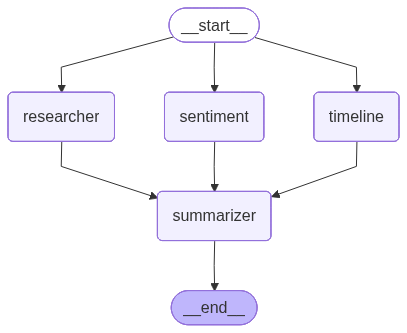

In [50]:

print("[PARALLEL] Graph compiled")
show_graph(parallel_app, "Parallel Agents Pattern")

In [53]:
result = parallel_app.invoke({
    "topic": "Artificial Intelligence in Healthcare",
    "research": "",
    "sentiment": "",
    "timeline": "",
    "summary": "",
    "steps_done": []
})

print(result)

[RESEARCHER] Running...
[SENTIMENT] Running...
[TIMELINE] Running...
[SUMMARIZER] Combining results...
{'topic': 'Artificial Intelligence in Healthcare', 'research': '- **Definition**: Artificial Intelligence (AI) in healthcare refers to the use of algorithms and software to approximate human cognition in the analysis, interpretation, and understanding of complex medical data.\n\n- **Applications**:\n  - **Diagnostic Assistance**: AI systems can analyze medical images (e.g., X-rays, MRIs) to assist radiologists in identifying conditions such as tumors or fractures.\n  - **Predictive Analytics**: AI can predict patient outcomes by analyzing historical data, helping in early intervention and personalized treatment plans.\n  - **Natural Language Processing (NLP)**: AI can process and analyze unstructured data from clinical notes, enabling better patient record management and insights.\n  - **Robotic Surgery**: AI-powered robotic systems can assist surgeons in performing complex procedures